In [41]:
from agents.aif.jax.aif import ActiveInferenceAgent
import axelrod as axl

In [42]:
aif_agent = ActiveInferenceAgent(
    pB_scale=1,
    gamma=1,
    alpha=1,
    bias=0.5,
    cooperative_preference=False,
    policy_len=5,
    update_interval=10,
    seed=42,
    lr_B=1,
    action_selection="deterministic",
    use_states_info_gain=True,
    use_param_info_gain=True,
    use_utility=True,
    use_noisy_observation_model=True,
)

tft = axl.TitForTat()

In [43]:
match = axl.Match((aif_agent, tft), turns=1000, noise=0.05)

In [44]:
match.play()
match.final_score()

(np.int64(2755), np.int64(2985))

In [45]:
aif_agent.agent.B[0].shape

(1, 5, 5, 2)

In [46]:
aif_agent.agent.q_pi

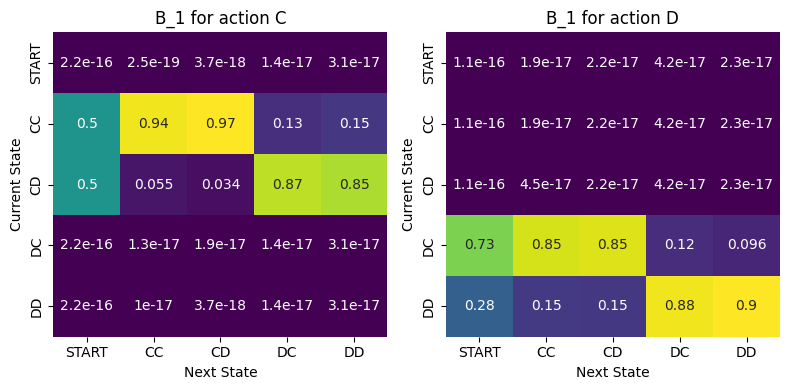

In [47]:
from agents.aif.jax.aif import plot_B_1

plot_B_1(
    aif_agent.agent.B[0].reshape((5, 5, 2))
)

Entropy matrix shape: (5, 2)


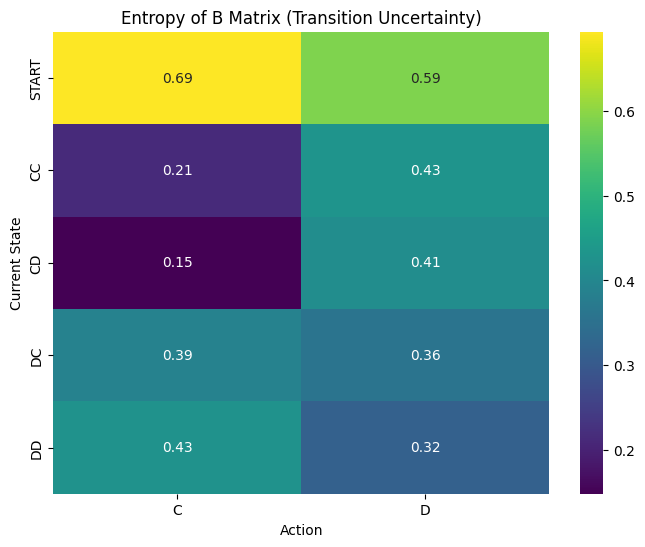

In [48]:
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_entropy(probs):
    """
    Calculate Shannon entropy of a probability distribution.
    probs: array-like, probabilities summing to 1 along the last axis (or specified axis).
    """
    # Avoid log(0) by adding a small epsilon or masking
    probs = jnp.array(probs)
    log_probs = jnp.log(probs + 1e-12)
    entropy = -jnp.sum(probs * log_probs, axis=0)
    return entropy

# Extract pB from the agent
# aif_agent.agent.pB is a list of arrays (one per factor), here we only have one factor
# Shape of pB[0]: (1, num_states, num_states, num_actions) -> (1, 5, 5, 2)
pB = aif_agent.agent.pB[0]

# Calculate expected B matrix (mean of Dirichlet)
# E[B] = alpha_i / sum(alpha)
B_mean = aif_agent.agent.B[0]

# Remove batch dimension if present
if B_mean.shape[0] == 1:
    B_mean = B_mean[0]

# B_mean shape: (num_states, num_states, num_actions) -> (5, 5, 2)
# Dimensions: (next_state, current_state, action)

# Calculate entropy along the next_state dimension (axis 0)
entropy_B = calculate_entropy(B_mean)

# entropy_B shape: (num_states, num_actions) -> (5, 2)
# Dimensions: (current_state, action)

print("Entropy matrix shape:", entropy_B.shape)

# Plotting
states_labels = ["START", "CC", "CD", "DC", "DD"]
actions_labels = ["C", "D"]

plt.figure(figsize=(8, 6))
sns.heatmap(entropy_B, annot=True, cmap="viridis", 
            xticklabels=actions_labels, yticklabels=states_labels)
plt.title("Entropy of B Matrix (Transition Uncertainty)")
plt.xlabel("Action")
plt.ylabel("Current State")
plt.show()